In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('ForeignGifts_dummyCoded.csv',low_memory=False)
df.head()

df_filtered =  df.loc[(df["is_public"] == 1) & (df["Gift Type"] == "Monetary Gift")]

df_pI = df_filtered.loc[df_filtered["public_ivy_core"] == 1]


df_uva = df_filtered.loc[df_filtered["Institution Name"] == "University of Virginia"]

df_filtered.head(3).T

df_pI.head(3).T

,4451,4452,4456
Unnamed: 0,4451,4452,4456
ID,4452,4453,4457
OPEID,131200,131200,131200
Institution Name,"University of California, Berkeley","University of California, Berkeley","University of California, Berkeley"
City,Berkeley,Berkeley,Berkeley
State,CA,CA,CA
Foreign Gift Received Date,41677,41683,41702
Foreign Gift Amount,274913,250000,5000000
Gift Type,Monetary Gift,Monetary Gift,Monetary Gift
Country of Giftor,SWITZERLAND,KOREA,ENGLAND


In [2]:
df_uva

,Unnamed: 0,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name,is_public,giftor_category,region,public_ivy_core,public_ivy_expanded
26235,26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police,1,Individual,Europe & Central Asia,1,1
26237,26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute,1,Academic/Research Institution,Middle East & North Africa,1,1
26242,26242,26243,374500,University of Virginia,Charlottesville,VA,41928,10000,Monetary Gift,ISRAEL,Atox Bio Ltd.,1,Industry/Corporate,Middle East & North Africa,1,1
26243,26243,26244,374500,University of Virginia,Charlottesville,VA,41929,9825,Monetary Gift,ENGLAND,TauRx Therapeutics Ltd,1,Industry/Corporate,Europe & Central Asia,1,1
26244,26244,26245,374500,University of Virginia,Charlottesville,VA,41948,6979,Monetary Gift,ISRAEL,US-Israel Binational Sci Fdn,1,Individual,Middle East & North Africa,1,1
26245,26245,26246,374500,University of Virginia,Charlottesville,VA,41948,5612,Monetary Gift,ISRAEL,US-Israel Binational Sci Fdn,1,Individual,Middle East & North Africa,1,1
26246,26246,26247,374500,University of Virginia,Charlottesville,VA,41956,310001,Monetary Gift,BANGLADESH,Intl Ctr for Diarrhoeal Disease,1,Individual,South Asia,1,1
26248,26248,26249,374500,University of Virginia,Charlottesville,VA,41984,68910,Monetary Gift,ENGLAND,Kirkhouse Trust,1,Charitable Organization,Europe & Central Asia,1,1
26249,26249,26250,374500,University of Virginia,Charlottesville,VA,41991,321029,Monetary Gift,ENGLAND,Charles Aid Foundation,1,Charitable Organization,Europe & Central Asia,1,1
26255,26255,26256,374500,University of Virginia,Charlottesville,VA,42153,53452,Monetary Gift,ENGLAND,Kirkhouse Trust,1,Charitable Organization,Europe & Central Asia,1,1


I used core public ivy league classification as they are comparable public flagship universities with impeccable reputations and 

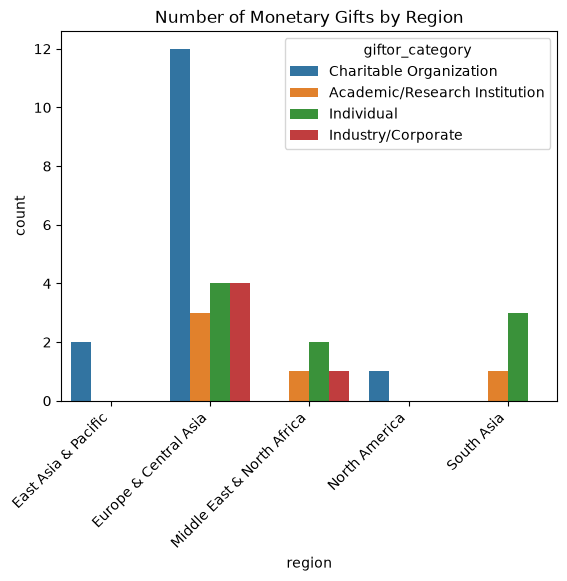

sum  count
region                     giftor_category                              
East Asia & Pacific        Charitable Organization         805000      2
Europe & Central Asia      Academic/Research Institution    86783      3
                           Charitable Organization        1347335     12
                           Individual                     2116035      4
                           Industry/Corporate             1509825      4
Middle East & North Africa Academic/Research Institution     8187      1
                           Individual                       12591      2
                           Industry/Corporate               10000      1
North America              Charitable Organization         900000      1
South Asia                 Academic/Research Institution      339      1
                           Individual                      585507      3

In [ ]:
summaryUVA = df_uva.groupby(["region", "giftor_category"])["Foreign Gift Amount"].agg(sum = "sum", count = "count")
sns.barplot( data=summaryUVA, x='region', y='count', hue='giftor_category', legend=True )
plt.xticks(rotation=45, ha="right")
plt.title("Number of Monetary Gifts by Region")
plt.show()


#uva_pct = (summmaryUVA.sum() / summaryUVA.sum().sum() * 100).round(1)

summaryUVA

In [ ]:
summaryUVA['percentDollars'] = (summaryUVA['sum'] / summaryUVA['sum'].sum() * 100).round(1)
summaryUVA['percentcount'] = (summaryUVA['count'] / summaryUVA['count'].sum() * 100).round(1)
summaryUVA

                                                              sum  count  \
region                     giftor_category                                 
East Asia & Pacific        Charitable Organization         805000      2   
Europe & Central Asia      Academic/Research Institution    86783      3   
                           Charitable Organization        1347335     12   
                           Individual                     2116035      4   
                           Industry/Corporate             1509825      4   
Middle East & North Africa Academic/Research Institution     8187      1   
                           Individual                       12591      2   
                           Industry/Corporate               10000      1   
North America              Charitable Organization         900000      1   
South Asia                 Academic/Research Institution      339      1   
                           Individual                      585507      3   

           

In [10]:
import plotly.graph_objects as go


giftor = 'region'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df_uva.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)



fig.show()



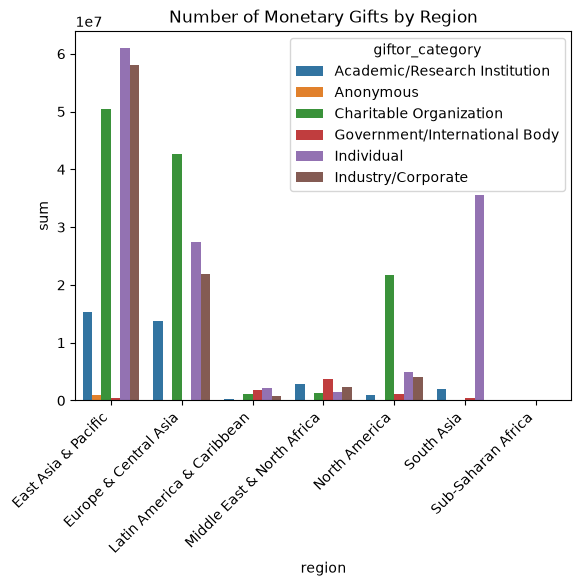

In [16]:
summarypIO = df_pI. groupby(["region", "giftor_category"])["Foreign Gift Amount"].agg(sum = "sum", count = "count")
sns.barplot( data=summarypIO, x='region', y='sum', hue='giftor_category', legend=True )
plt.xticks(rotation=45, ha="right")
plt.title("Number of Monetary Gifts by Region")
plt.show()

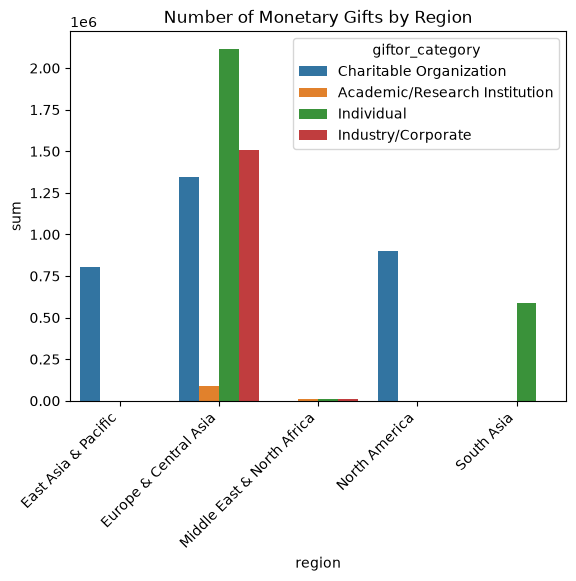

In [17]:
sns.barplot( data=summaryUVA, x='region', y='sum', hue='giftor_category', legend=True )
plt.xticks(rotation=45, ha="right")
plt.title("Number of Monetary Gifts by Region")
plt.show()

In [6]:
#percentiles as in example sheet
totalsMoney = df_filtered.groupby("Institution Name")["Foreign Gift Amount"].sum()

uvaRankPublic = totalsMoney.rank(ascending=False, method='min')["University of Virginia"]
uvaPertPublic = totalsMoney.rank(pct=True)["University of Virginia"] * 100

df_pI = df_filtered[df_filtered["public_ivy_core"] == 1]
totalsPI = df_pI.groupby("Institution Name")["Foreign Gift Amount"].sum()

uvaRankPI = totalsPI.rank(ascending=False, method='min')["University of Virginia"]
uvaPertPI = totalsPI.rank(pct=True)["University of Virginia"] * 100

percUVA = [uvaRankPublic, uvaPertPublic, uvaRankPI, uvaPertPI]
percUVA


[np.float64(22.0),
 np.float64(72.72727272727273),
 np.float64(9.0),
 np.float64(42.857142857142854)]

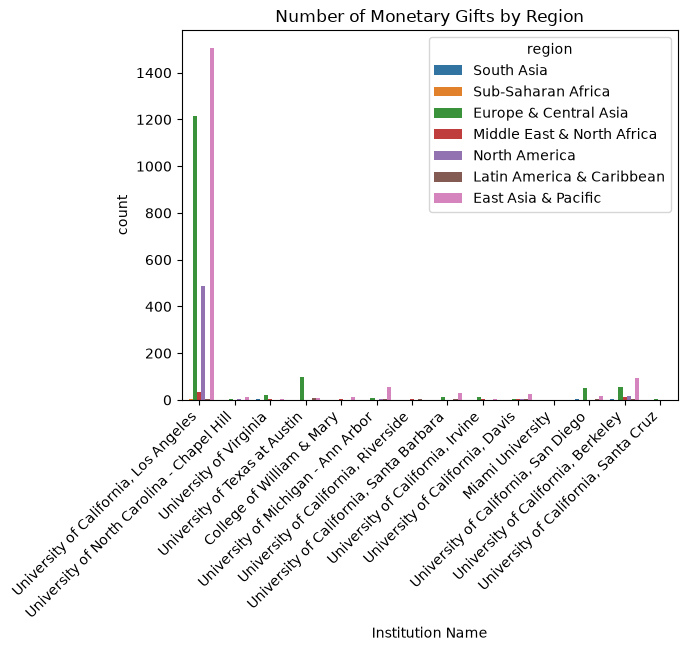

sum  \
region                     Institution Name                                       
South Asia                 University of California, Los Angeles            100   
Sub-Saharan Africa         University of California, Los Angeles            202   
Europe & Central Asia      University of North Carolina - Chapel Hill     15000   
Middle East & North Africa University of Virginia                         30778   
North America              University of Texas at Austin                  50000   
Latin America & Caribbean  University of California, Los Angeles         100254   
North America              College of William & Mary                     263618   
Middle East & North Africa University of Michigan - Ann Arbor            290625   
                           University of California, Riverside           347000   
                           University of California, Los Angeles         391125   
Latin America & Caribbean  University of Michigan - Ann Arbor            449284   
Middle East & North Africa University of Texas at Austin                 499968   
South Asia                 University of Virginia                        585846   
Latin America & Caribbean  University of California, Santa Barbara       640753   
North America              University of California, Irvine              689082   
Latin America & Caribbean  University of Texas at Austin                 724620   
East Asia & Pacific        University of Virginia                        805000   
                           University of Texas at Austin                 827804   
                           College of William & Mary                     858350   
                           University of California, Irvine              869998   
Middle East & North Africa University of California, Irvine              870000   
Latin America & Caribbean  University of California, Davis               880075   
North America              University of Virginia                        900000   
Latin America & Caribbean  University of California, Riverside           908426   
Middle East & North Africa Miami University                              948751   
Latin America & Caribbean  University of California, San Diego          1060000   
                           University of California, Berkeley           1301244   
North America              University of North Carolina - Chapel Hill   1342635   
Middle East & North Africa University of California, Davis              1468443   
North America              University of California, Los Angeles        1584186   
Europe & Central Asia      University of California, Riverside          1650000   
                           University of California, Santa Cruz         1923172   
Middle East & North Africa College of William & Mary                    2262530   
South Asia                 University of California, Berkeley           2423050   
North America              University of California, Davis              2799276   
Europe & Central Asia      University of California, Davis              2906603   
East Asia & Pacific        University of North Carolina - Chapel Hill   3117763   
Europe & Central Asia      University of California, Santa Barbara      4067824   
Middle East & North Africa University of California, Berkeley           4361955   
Europe & Central Asia      University of California, San Diego          4567803   
North America              University of Michigan - Ann Arbor           4574100   
Europe & Central Asia      University of Virginia                       5059978   
                           University of California, Irvine             6422757   
East Asia & Pacific        University of California, San Diego          8262810   
Europe & Central Asia      University of Michigan - Ann Arbor          10085424   
East Asia & Pacific        University of California, Santa Barbara     10475500   
                           University of California, Davis             10496577   
Europe & 

In [18]:
summarypI= df_pI.groupby(["region", "Institution Name"])["Foreign Gift Amount"].agg(sum = "sum", count = "count").sort_values("sum", ascending = True)
sns.barplot( data=summarypI, x='Institution Name', y='count', hue='region', legend=True )
plt.xticks(rotation=45, ha="right")
plt.title("Number of Monetary Gifts by Region")
plt.show()

summarypI

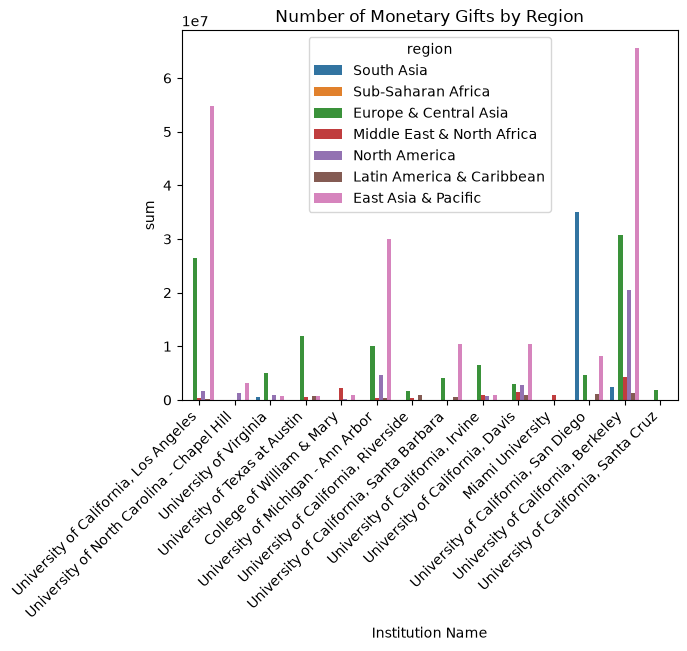

In [19]:
sns.barplot( data=summarypI, x='Institution Name', y='sum', hue='region', legend=True )
plt.xticks(rotation=45, ha="right")
plt.title("Number of Monetary Gifts by Region")
plt.show()

In [18]:
# UVA outside Europe - charity %
uva = df_filtered[df_filtered["Institution Name"] == "University of Virginia"]
uvaNotEuro= uva[uva["region"] != "Europe & Central Asia"]

summaryUVANotEuro = uvaNotEuro.groupby("giftor_category")["Foreign Gift Amount"].agg(sum="sum", count="count")
summaryUVANotEuro['percentagedollars'] = (summaryUVANotEuro['sum'] / summaryUVANotEuro['sum'].sum() * 100).round(1)

summaryUVANotEuro






,sum,count,percentagedollars
giftor_category,,,
Academic/Research Institution,8526,2,0.4
Charitable Organization,1705000,3,73.4
Individual,598098,5,25.8
Industry/Corporate,10000,1,0.4


In [22]:
uvaEuro = uva[uva["region"] == "Europe & Central Asia"]

summaryUVAEuro = uvaEuro.groupby("giftor_category")["Foreign Gift Amount"].agg(sum="sum", count="count")
summaryUVAEuro['percentagedollars'] = (summaryUVAEuro['sum'] / summaryUVAEuro['sum'].sum() * 100).round(1)
summaryUVAEuro

,sum,count,percentagedollars
giftor_category,,,
Academic/Research Institution,86783,3,1.7
Charitable Organization,1347335,12,26.6
Individual,2116035,4,41.8
Industry/Corporate,1509825,4,29.8


In [16]:
df_pI = df_filtered[df_filtered["public_ivy_core"] == 1]
pINEuro = df_pI[df_pI["region"] != "Europe & Central Asia"]

summary_pINEURO = pINEuro.groupby("giftor_category")["Foreign Gift Amount"].agg(sum="sum", count="count")
summary_pINEURO['percentagedollars'] = (summary_pINEURO['sum'] / summary_pINEURO['sum'].sum() * 100).round(1)

summary_pINEURO

,sum,count,percentagedollars
giftor_category,,,
Academic/Research Institution,21357132,80,7.8
Anonymous,1000000,2,0.4
Charitable Organization,74545944,90,27.2
Government/International Body,7257806,17,2.6
Individual,105061869,1944,38.3
Industry/Corporate,65103411,268,23.7


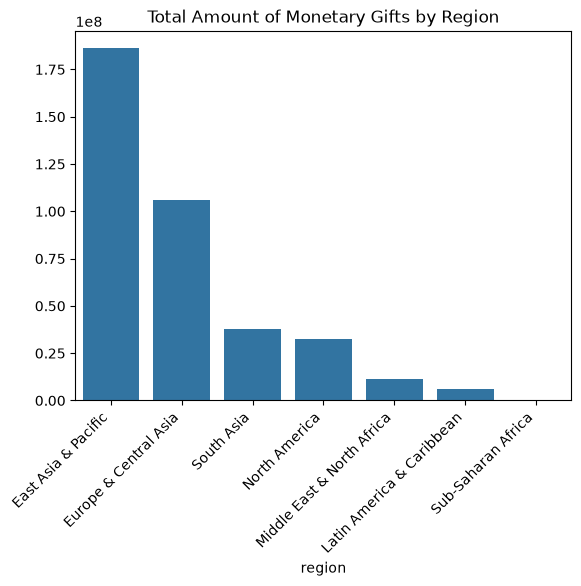

In [20]:
region_sums = df_pI.groupby("region")["Foreign Gift Amount"].sum().sort_values(ascending=False)

sns.barplot(x=region_sums.index, y=region_sums.values)
plt.xticks(rotation=45, ha="right")
plt.title("Total Amount of Monetary Gifts by Region")
plt.show()

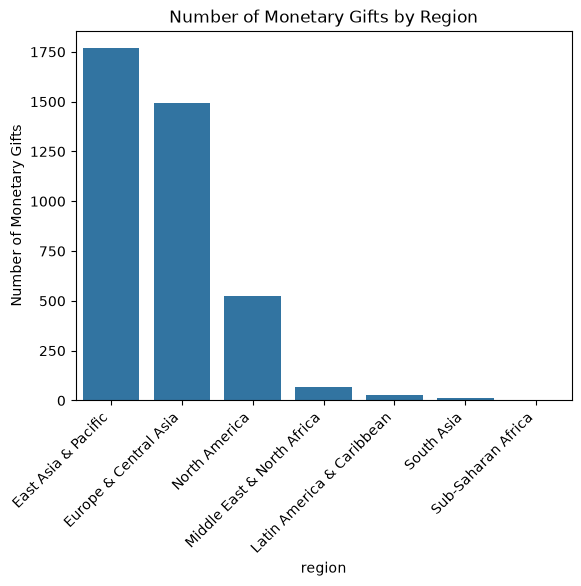

In [21]:
region_counts = df_pI.groupby("region")["Foreign Gift Amount"].count().sort_values(ascending=False)

sns.barplot(x=region_counts.index, y=region_counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Monetary Gifts")
plt.title("Number of Monetary Gifts by Region")
plt.show()

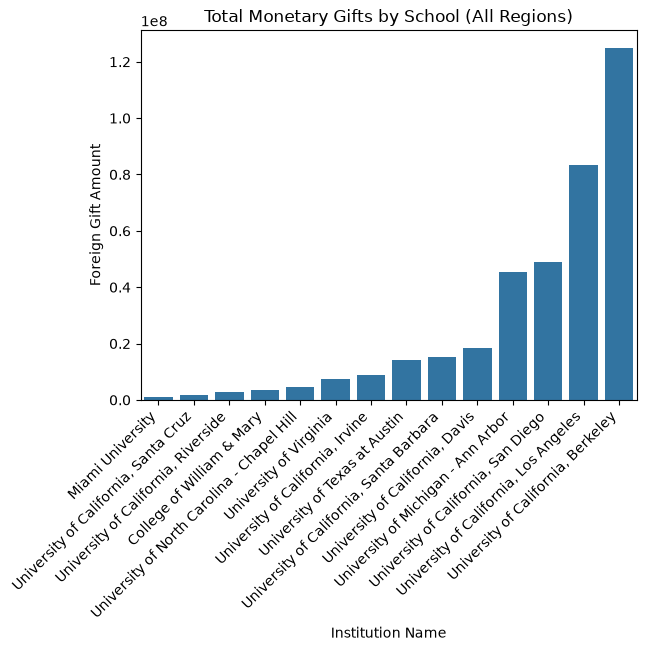

In [3]:
summarypI = df_pI.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=True)

sns.barplot(data=summarypI.reset_index(), x="Institution Name", y="Foreign Gift Amount")
plt.xticks(rotation=45, ha="right")
plt.title("Total Monetary Gifts by School (All Regions)")
plt.show()

In [ ]:
df_pI[df_pI["region"] == "East Asia & Pacific" ].groupby(["Institution Name"])["Foreign Gift Amount"].count().sort_values(ascending= False)

Institution Name
University of California, Los Angeles         1506
University of California, Berkeley              95
University of Michigan - Ann Arbor              54
University of California, Santa Barbara         31
University of California, Davis                 25
University of California, San Diego             19
College of William & Mary                       12
University of North Carolina - Chapel Hill      12
University of Texas at Austin                    8
University of California, Irvine                 3
University of Virginia                           2
Name: Foreign Gift Amount, dtype: int64

In [ ]:
df_pI[df_pI["region"] == "East Asia & Pacific" ].groupby(["Institution Name"])["Foreign Gift Amount"].sum().sort_values(ascending= False)

Institution Name
University of California, Berkeley            65605206
University of California, Los Angeles         54808567
University of Michigan - Ann Arbor            29937912
University of California, Davis               10496577
University of California, Santa Barbara       10475500
University of California, San Diego            8262810
University of North Carolina - Chapel Hill     3117763
University of California, Irvine                869998
College of William & Mary                       858350
University of Texas at Austin                   827804
University of Virginia                          805000
Name: Foreign Gift Amount, dtype: int64

In [ ]:
df_pI[df_pI["region"] == "Europe & Central Asia" ].groupby(["Institution Name"])["Foreign Gift Amount"].sum().sort_values(ascending= False)

Institution Name
University of California, Berkeley            30700797
University of California, Los Angeles         26515827
University of Texas at Austin                 12004075
University of Michigan - Ann Arbor            10085424
University of California, Irvine               6422757
University of Virginia                         5059978
University of California, San Diego            4567803
University of California, Santa Barbara        4067824
University of California, Davis                2906603
University of California, Santa Cruz           1923172
University of California, Riverside            1650000
University of North Carolina - Chapel Hill       15000
Name: Foreign Gift Amount, dtype: int64

In [ ]:
df_pI[df_pI["region"] == "Europe & Central Asia" ].groupby(["Institution Name"])["Foreign Gift Amount"].count().sort_values(ascending= False)

Institution Name
University of California, Los Angeles         1215
University of Texas at Austin                   99
University of California, Berkeley              56
University of California, San Diego             51
University of Virginia                          23
University of California, Irvine                14
University of California, Santa Barbara         11
University of Michigan - Ann Arbor               9
University of California, Santa Cruz             6
University of California, Davis                  4
University of North Carolina - Chapel Hill       2
University of California, Riverside              1
Name: Foreign Gift Amount, dtype: int64

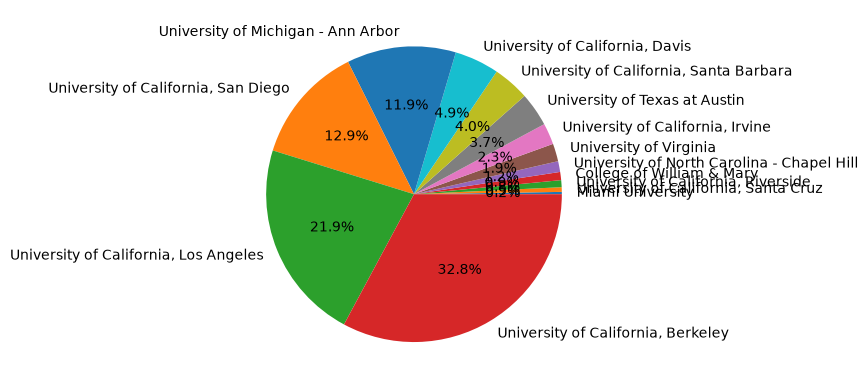

In [ ]:
plt.pie(summarypI_total, labels=summarypI_total.index, autopct='%1.1f%%')
plt.show()

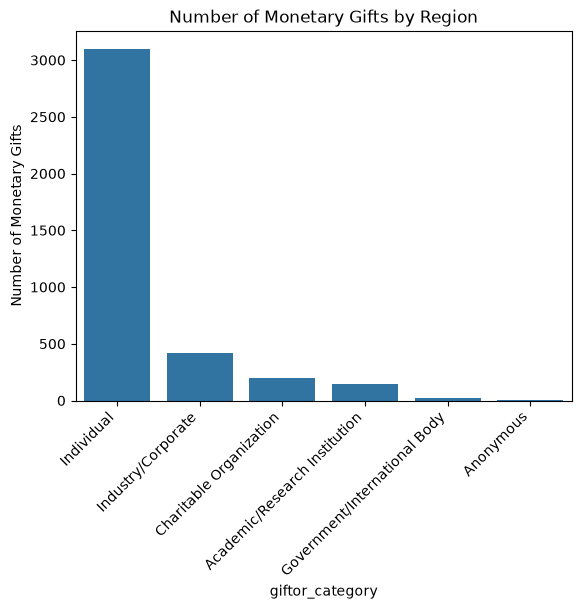

In [ ]:
giftorcat_counts = df_pI.groupby("giftor_category")["Foreign Gift Amount"].count().sort_values(ascending=False)

sns.barplot(x=giftorcat_counts.index, y=giftorcat_counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Monetary Gifts")
plt.title("Number of Monetary Gifts by Cat")
plt.show()

In [ ]:
#Need some percentages rather than numbers

summaryUVA = df_filtered.groupby("region")["Foreign Gift Amount"].agg(sum="sum", count="count")

summaryUVA['percentdollars'] = (summaryUVA['sum'] / summaryUVA['sum'].sum() * 100).round(1)
summaryUVA['percentcount'] = (summaryUVA['count'] / summaryUVA['count'].sum() * 100).round(1)

summaryUVA = summaryUVA.sort_values('percentdollars', ascending=False)

summaryUVA

                                  sum  count  percentdollars  percentcount
region                                                                    
East Asia & Pacific         299724398   2170            38.1          41.9
Europe & Central Asia       209189547   1868            26.6          36.1
Middle East & North Africa  128728665    292            16.4           5.6
North America                64715906    707             8.2          13.7
South Asia                   46947639     34             6.0           0.7
Latin America & Caribbean    34491342     92             4.4           1.8
Sub-Saharan Africa            3259987     11             0.4           0.2


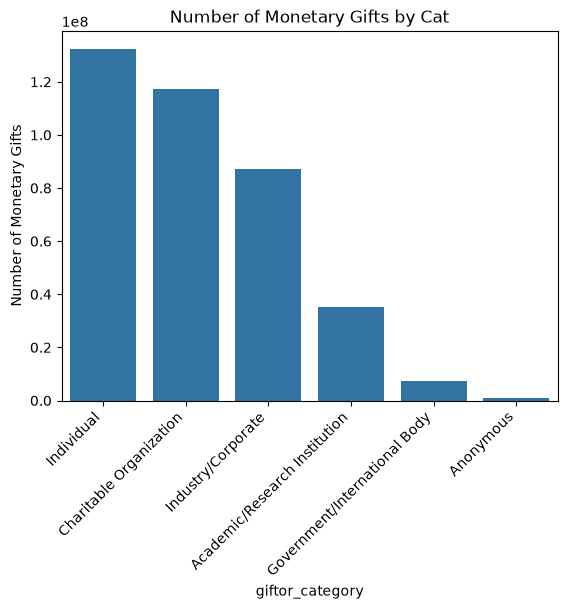

In [23]:
giftorcat_sum= df_pI.groupby("giftor_category")["Foreign Gift Amount"].sum().sort_values(ascending=False)

sns.barplot(x=giftorcat_sum.index, y=giftorcat_sum.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Monetary Gifts")
plt.title("Number of Monetary Gifts by Cat")
plt.show()

In [14]:
giftorcat_sum

giftor_category
Individual                       132541491
Charitable Organization          117274592
Industry/Corporate                87019089
Academic/Research Institution     35139066
Government/International Body      7271184
Anonymous                          1000000
Name: Foreign Gift Amount, dtype: int64

In [4]:
summary = df_filtered.groupby("Institution Name")["Foreign Gift Amount"].agg(count="count", sum="sum")

summary["percentile"] = summary["sum"].rank(pct=True) * 100

summary.sort_values("percentile", ascending=False)

,count,sum,percentile
Institution Name,,,
"University of California, Berkeley",189,124905001,100.000000
"University of California, Los Angeles",3252,83400261,98.701299
Purdue University,99,75504368,97.402597
Texas A&M University,70,54879197,96.103896
"University of California, San Diego",75,48890613,94.805195
...,...,...,...
University of Oklahoma,1,56000,6.493506
University of Colorado Colorado Springs,5,33296,5.194805
"Rutgers, the State University of New Jersey",2,21830,3.896104


In [8]:
summary = df_filtered[df_filtered["region"] == "East Asia & Pacific"].groupby("Institution Name")["Foreign Gift Amount"].agg(count="count", sum="sum")

summary["percentile"] = summary["sum"].rank(pct=True) * 100

summary.sort_values("percentile", ascending=False)

,count,sum,percentile
Institution Name,,,
"University of California, Berkeley",95,65605206,100.000000
"University of California, Los Angeles",1506,54808567,98.113208
University of Michigan - Ann Arbor,54,29937912,96.226415
University of Texas MD Anderson Cancer Center,15,20320107,94.339623
Purdue University,28,14726763,92.452830
University of Illinois at Urbana-Champaign,18,14275684,90.566038
"University of California, Davis",25,10496577,88.679245
"University of California, Santa Barbara",31,10475500,86.792453
"University of California, San Diego",19,8262810,84.905660
